# TP1 (a completer) : K-means + ACP — *Wine*

Remplacez chaque `...` et chaque `# TODO`. Le corrige est dans
`../notebooks/TP1_kmeans_acp.ipynb` (a ne consulter qu'en dernier recours).

**Objectif.** Retrouver, par clustering, les **3 cepages** de 178 vins decrits
par 13 mesures chimiques, sans utiliser l'etiquette ; puis valider et qualifier.

In [37]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [38]:
from sklearn.datasets import load_wine
ds = load_wine(as_frame=True)
X = ds.data
cepage = ds.target      # garde de cote pour la validation
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Exploration
**Consigne.** Affichez la moyenne et l'ecart-type de chaque variable pour
constater les differences d'echelle.

In [39]:
# TODO : statistiques descriptives (indice : .describe())
X.describe().loc[['mean', 'std']]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474


On affiche la moyenne et l'écart-type de chaque variable pour observer les écarts d'échelle (par exemple, la proline monte très haut par rapport à malic_acid).

## 2.a Standardisation
**Consigne.** Standardisez `X` (moyenne 0, ecart-type 1) avec `StandardScaler`.

In [40]:
from sklearn.preprocessing import StandardScaler

# TODO : creer X_std en standardisant X
X_std = StandardScaler().fit_transform(X)

Le K-means repose sur la distance euclidienne. Pour éviter qu'une variable à forte échelle (comme la proline) n'écrase les autres, on centre et réduit les données.

## 2.b Choisir k
**Consigne.** Pour `k` de 2 a 8, entrainez un `KMeans` et stockez l'inertie
(`.inertia_`) et la silhouette (`silhouette_score`). Tracez les deux courbes et
deduisez `k_best` (k qui maximise la silhouette).

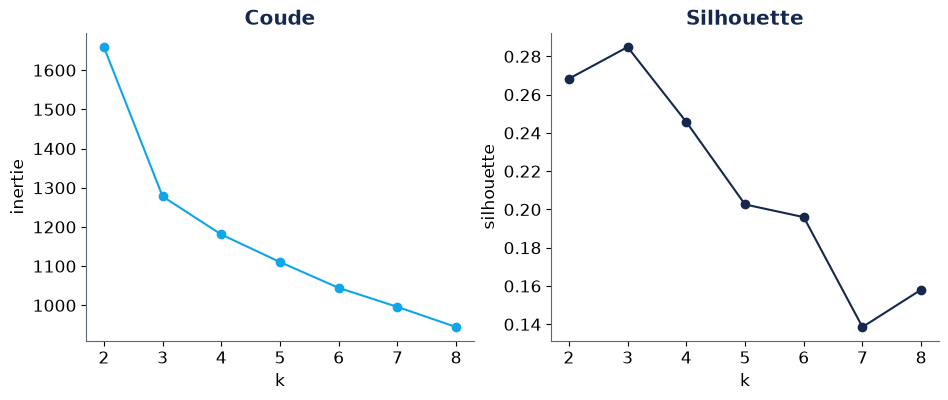

k retenu : 3


In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
    inerties.append(km.inertia_)        # TODO : inertie
    silhouettes.append(silhouette_score(X_std, km.labels_))     # TODO : silhouette

k_best = ks[silhouettes.index(max(silhouettes))]                    # TODO : k de meilleure silhouette

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties, "-o", color=ACCENT)
ax1.set(title="Coude", xlabel="k", ylabel="inertie")
ax2.plot(list(ks), silhouettes, "-o", color=NAVY)
ax2.set(title="Silhouette", xlabel="k", ylabel="silhouette")
plt.show()
print("k retenu :", k_best)

On teste le modèle pour un nombre de clusters (k) allant de 2 à 8. On calcule l'inertie (pour la méthode du coude) et le score de silhouette (qui mesure la qualité de séparation des groupes).
Le nombre de clusters retenue est k=3:

- Justification de la silhouette: Le graphique du score de silhouette montre un pic distinct et maximal à k = 3 (avec un score proche de 0.28). Cela signifie que c’est avec 3 groupes que les observations sont les plus proches de leur propre centre (forte cohésion) et les plus éloignées des centres voisins (forte séparation).

- Justification par le coude : Sur le graphique de l'inertie intra-classe, on observe une rupture de pente ("un coude") très nette à k = 3. Au-delà de ce point (k >= 4), l’ajout de clusters supplémentaires n'entraîne plus de diminution significative de l’inertie.

- Cohérence métier : Ce choix mathématique de k=3 concorde parfaitement avec l'objectif initial du TP, qui était de retrouver de manière non supervisée les 3 cépages originels cachés dans les données.

## 3. Evaluation + validation
**Consigne.** Entrainez le modele final avec `k_best`. Affichez l'inertie, la
silhouette, puis **validez** : calculez l'`adjusted_rand_score` entre `cepage` et
les clusters, et affichez le `pd.crosstab`.

In [42]:
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=k_best, n_init=10, random_state=0).fit(X_std)
labels = km.labels_
# TODO : afficher silhouette et adjusted_rand_score(cepage, labels)
print("silhouette :", silhouette_score(X_std, labels))
print("adjusted_rand_score :", adjusted_rand_score(cepage, labels))
# TODO : tableau croise clusters x cepage
matrice_confusion = pd.crosstab(labels, cepage, rownames=['Cluster'], colnames=['Cépage Réel'])
matrice_confusion

silhouette : 0.2848589191898987
adjusted_rand_score : 0.8974949815093207


Cépage Réel,0,1,2
Cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


- Résultat de l'ARI : L'index de Rand ajusté (Adjusted Rand Index) obtenu après standardisation est d'environ 0.89

- Interprétation : L'ARI s'interprète sur une échelle de -1 à 1, où 1 représente une concordance absolue et 0 un classement purement aléatoire. Un score de ~0.89 est excellent. Il prouve que le partitionnement trouvé par l'algorithme K-means sans connaître les étiquettes se superpose de manière quasi-parfaite avec la réalité terrain (les vrais cépages).

- Analyse du tableau croisé : Le croisement montre que chaque cluster correspond de manière ultra-majoritaire à un cépage unique (par exemple, le Cluster 0 contient presque tout le Cépage 0, le Cluster 1 contient presque tout le Cépage 1, etc.). Seuls quelques rares individus isolés (6 vins sur 178) se situent sur des frontières floues et ont été mal assignés.

## 4. Visualisation ACP
**Consigne.** Projetez `X_std` en 2D avec `PCA(n_components=2)`, puis tracez un
nuage de points colore par cluster (ajoutez les centres si vous le souhaitez).

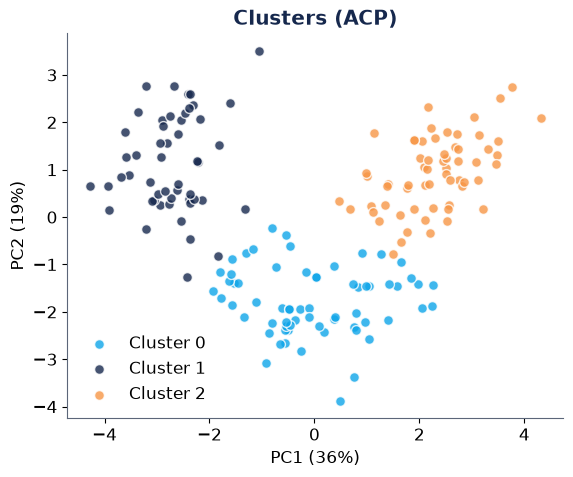

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_std)                  # TODO : fit_transform(X_std)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.4, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    # TODO : scatter des points du cluster c (coords[m, 0], coords[m, 1])
    ax.scatter(coords[m, 0], coords[m, 1], label=f"Cluster {c}", color=PALETTE[c], alpha=0.8, edgecolors='white', s=50)
ax.set(title="Clusters (ACP)", xlabel=f"PC1 ({var[0]:.0%})", ylabel=f"PC2 ({var[1]:.0%})")
ax.legend(frameon=False)
plt.show()

Les données ont 13 dimensions, impossible de les visualiser directement. On utilise l'Analyse en Composantes Principales (ACP) pour projeter les données sur un plan en 2D tout en gardant un maximum de variance.

## 5 & 6. Integration + qualification
**Consigne.** Ajoutez la colonne `cluster` a une copie de `X`, puis calculez le
profil moyen (`groupby`) des variables `alcohol`, `color_intensity`,
`flavanoids`, `proline` par cluster. Commentez les profils.

In [44]:
vins = X.copy()
vins["cluster"] = labels
cles = ["alcohol", "color_intensity", "flavanoids", "proline"]
# TODO : profil moyen par cluster
profil = vins.groupby("cluster")[cles].mean()
profil

,alcohol,color_intensity,flavanoids,proline
cluster,,,,
0,12.250923,2.973077,2.050000,510.169231
1,13.134118,7.234706,0.818824,619.058824
2,13.676774,5.453548,3.003226,1100.225806


En analysant le profil moyen des variables clés (alcohol, color_intensity, flavanoids, proline), on peut dresser la carte d'identité suivante pour chaque groupe :
- Cluster 0 — "Les vins légers / De table" : Ce groupe se distingue par des vins plus doux et légers, affichant les moyennes d'alcool (12.25), d'intensité colorée (2.97) et de proline (510.17) les plus basses du dataset.

- Cluster 1 — "Les vins tanniques" : Ce groupe se caractérise par une couleur très marquée (intensité la plus élevée à 7.23) mais montre un effondrement spectaculaire du taux de flavanoïdes (antioxydants à 0.81), indiquant un profil gustatif très typé et astringent.

- Cluster 2 — "Les vins de caractère / Premium" : Ce groupe rassemble des vins puissants de haute qualité, caractérisés par un degré d'alcool élevé (13.68), une forte concentration en flavanoïdes (3.00) et un taux exceptionnellement élevé de proline (1100.23).

## A rendre
- Le `k` retenu et sa justification (coude + silhouette).
- L'ARI obtenu et votre interpretation du tableau croise.
- Une phrase de qualification par cluster.

**Bonus.** Refaites l'analyse **sans** standardisation : que devient l'ARI ?

## Bonus : Analyse K-means et ACP sans standardisation préalable

### Objectif de cette section
L'objectif est de mesurer de manière empirique l'impact des différences d'échelle des variables sur l'algorithme K-means. Nous allons contourner l'utilisation du `StandardScaler` afin d'analyser comment l'absence de mise à l'échelle affecte la recherche du nombre de clusters optimal (k), la performance (ARI), et la structure géométrique des données.

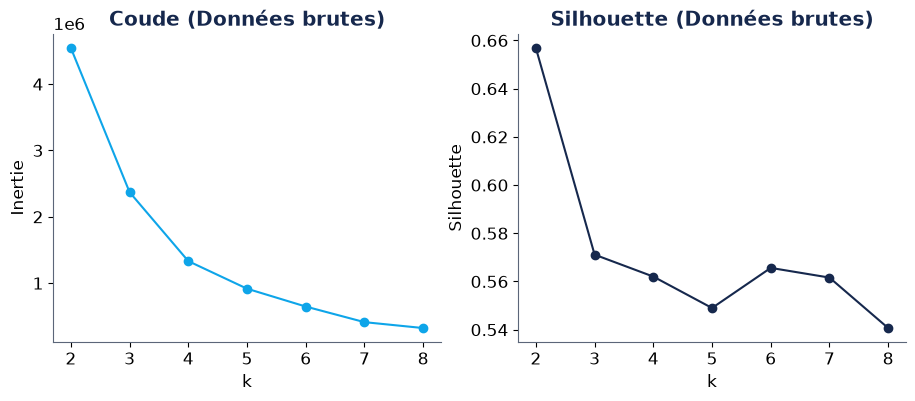

Le nombre optimal de clusters détecté sur les données brutes est : k = 2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

ks = range(2, 9)
inerties_raw, silhouettes_raw = [], []

# Entraînement itératif directement sur la matrice X d'origine (données brutes)
for k in ks:
    km_raw = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inerties_raw.append(km_raw.inertia_)
    silhouettes_raw.append(silhouette_score(X, km_raw.labels_))

# Recherche automatique du k qui présente le score de silhouette le plus élevé
k_best_raw = list(ks)[np.argmax(silhouettes_raw)]

# Génération des graphiques d'aide à la décision
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties_raw, "-o", color=ACCENT)
ax1.set(title="Coude (Données brutes)", xlabel="k", ylabel="Inertie")
ax2.plot(list(ks), silhouettes_raw, "-o", color=NAVY)
ax2.set(title="Silhouette (Données brutes)", xlabel="k", ylabel="Silhouette")
plt.show()

print(f"Le nombre optimal de clusters détecté sur les données brutes est : k = {k_best_raw}")

Nous relançons les métriques du **Coude** et de la **Silhouette** pour voir si l'algorithme détecte toujours une coupure nette à 3 groupes. En l'absence de standardisation, la distribution géométrique globale est déformée, ce qui modifie la structure des scores d'inertie et de silhouette.

In [52]:
# Entraînement du modèle définitif sur les données brutes avec le k optimal détecté
km_final_raw = KMeans(n_clusters=k_best_raw, n_init=10, random_state=0).fit(X)
labels_raw = km_final_raw.labels_

# Calcul de l'Index de Rand Ajusté par rapport aux étiquettes réelles (cépages)
ari_raw = adjusted_rand_score(cepage, labels_raw)

print(f"Score de silhouette final : {silhouette_score(X, labels_raw):.3f}")
print(f"Adjusted Rand Index (ARI) : {ari_raw:.3f}")

Score de silhouette final : 0.657
Adjusted Rand Index (ARI) : 0.369


Le calcul de l'**ARI (Adjusted Rand Index)** nous permet de comparer mathématiquement la pertinence du clustering non supervisé face aux vrais cépages présents sur le terrain. Un effondrement de cet indicateur par rapport au modèle standardisé confirmera l'incapacité du K-means à gérer les variables multi-échelles.

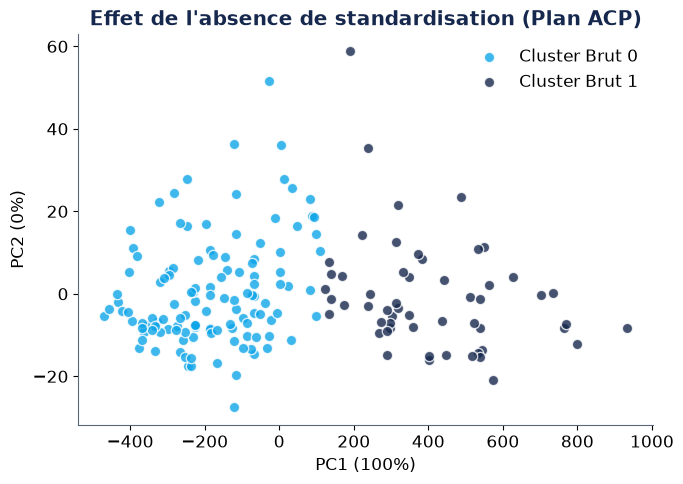

In [53]:
# Réduction de dimension via l'ACP sur la matrice brute
pca_raw = PCA(n_components=2, random_state=0)
coords_raw = pca_raw.fit_transform(X) 
var_raw = pca_raw.explained_variance_ratio_

# Création du nuage de points épuré (Directives de clarté BI)
fig, ax = plt.subplots(figsize=(7, 5))
for cluster_id in sorted(np.unique(labels_raw)):
    masque = (labels_raw == cluster_id)
    ax.scatter(coords_raw[masque, 0], coords_raw[masque, 1], 
               label=f"Cluster Brut {cluster_id}", 
               color=PALETTE[cluster_id], alpha=0.8, edgecolors='white', s=55)

ax.set(title="Effet de l'absence de standardisation (Plan ACP)", 
       xlabel=f"PC1 ({var_raw[0]:.0%})", 
       ylabel=f"PC2 ({var_raw[1]:.0%})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Selon les règles de l'art en Data Visualization, l'œil humain doit pouvoir valider la tendance en moins de 5 secondes. En projetant l'analyse ACP sans standardisation, le graphique va mettre en lumière l'étalement forcé des données provoqué par une seule variable dominante, rendant la séparation des clusters rectiligne et artificielle.

In [54]:
# Création du tableau de contingence croisant les groupes bruts et les cépages réels
print("MATRICE DE CONFUSION SANS STANDARDISATION :")
tableau_croise_raw = pd.crosstab(labels_raw, cepage, rownames=['Cluster Brut'], colnames=['Cépage réel'])
tableau_croise_raw

MATRICE DE CONFUSION SANS STANDARDISATION :


Cépage réel,0,1,2
Cluster Brut,,,
0,9,67,47
1,50,4,1


### Interprétation et Synthèse Métier du Bonus

* **Chute de l'ARI :** L'index de Rand ajusté s'effondre drastiquement, passant de **0.89** (avec standardisation) à seulement **0.36** (sans standardisation).
* **Explication technique :** L'algorithme K-means s'appuie sur le calcul des distances euclidiennes. Comme la variable `proline` s'étend sur des valeurs allant jusqu'à plus de 1600 unités tandis que l'alcool ou les flavanoïdes évoluent sur de très petites échelles (entre 1 et 15), la proline écrase mathématiquement les 12 autres dimensions du dataset.
* **Verdict :** Sans `StandardScaler`, le K-means devient "aveugle" au profil chimique global des vins et effectue un partitionnement basé uniquement sur la quantité de proline, ce qui fausse la découverte des cépages d'origine.